# Assoziationsanalyse — OpenFoodFacts

Dieses Notebook entdeckt automatisch Zusammenhänge zwischen Spalten im Datensatz:

| Datentyp | Methode | Wertebereich |
|---|---|---|
| Kategorisch | **Cramér's V** (Chi²-basiert) | 0 = kein, 1 = perfekter Zusammenhang |
| Numerisch | **Spearman ρ** (Rangkorrelation) | −1 bis +1 |

**RAM-Schutz:** `usecols`, dtype-Optimierung, Zufalls-Sampling (200k Zeilen für Chi²).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import combinations

## 1 · Konfiguration
Hier können Spalten, Sampling-Größe und Ausgabepfad angepasst werden.

In [8]:
CSV_PATH = "../en.openfoodfacts.org.products 2.csv"

# Kategorische Spalten → Cramér's V
CAT_COLS = [
    "countries_en",
    "origins_en",
    "packaging_en",
    "food_groups_en",
    "main_category_en",
    "nutriscore_grade",
    "nova_group",
    "labels_en",
]

# Numerische Spalten → Spearman ρ
NUM_COLS = [
    "energy_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "sodium_100g",
    "nutriscore_score",
]

SAMPLE_N    = 200_000   # Zeilen für Chi²-Analyse
MAX_CATS    = 30        # Maximale Kategorien pro Spalte in der Kontingenztafel
TOP_N_PAIRS = 10        # Anzahl stärkster Paare im Summary
OUTPUT_PNG  = "../Grafiken Meme/association_heatmaps.png"

## 2 · Daten laden & optimieren
Nur die benötigten Spalten werden eingelesen (`usecols`). Anschließend werden Datentypen optimiert, um RAM zu sparen.

In [9]:
needed = list(set(CAT_COLS + NUM_COLS))

print("Lade Daten (nur benötigte Spalten) …")
df = pd.read_csv(
    CSV_PATH,
    sep="\t",
    usecols=lambda c: c in needed,   # ~170 nicht benötigte Spalten überspringen
    low_memory=False,
    on_bad_lines="skip",
)

ram_vorher = df.memory_usage(deep=True).sum() / 1e6
print(f"  {len(df):,} Zeilen × {df.shape[1]} Spalten  ({ram_vorher:.0f} MB)")

# Kategorische Spalten als pandas Categorical → 4–10× weniger RAM
for c in CAT_COLS:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Nährwerte von float64 → float32 → 50 % Reduktion
for c in NUM_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")

ram_nachher = df.memory_usage(deep=True).sum() / 1e6
print(f"  Nach Optimierung: {ram_nachher:.0f} MB  (−{(1 - ram_nachher/ram_vorher)*100:.0f} %)")

Lade Daten (nur benötigte Spalten) …
  4,501,357 Zeilen × 18 Spalten  (870 MB)
  Nach Optimierung: 284 MB  (−67 %)


## 3 · Stichprobe für kategorische Analyse
Chi² auf 4,5 Mio. Zeilen würde jeden winzigen Effekt statistisch signifikant machen.  
200k Zeilen bieten mehr als genug statistische Power für Cramér's V > 0,05.

In [10]:
n_sample  = min(SAMPLE_N, len(df))
df_sample = df.sample(n=n_sample, random_state=42).copy()
print(f"Stichprobe: {n_sample:,} Zeilen")

Stichprobe: 200,000 Zeilen


## 4 · Cramér's V — kategorische Assoziationen
Cramér's V = √(χ² / (n · (k−1))) — normiert auf [0, 1], unabhängig von Stichprobengröße.

In [11]:
def cramers_v(a: pd.Series, b: pd.Series, max_cats: int = MAX_CATS) -> float:
    """Cramér's V zwischen zwei kategorischen Serien. Gibt NaN zurück bei zu wenig Daten."""
    mask = a.notna() & b.notna()
    a, b = a[mask], b[mask]
    if len(a) < 30:
        return np.nan

    # In plain object-Strings umwandeln — Categorical-Dtype blockiert .where() mit
    # unbekannten Werten ("__andere__" ist keine registrierte Kategorie)
    a = a.astype(str)
    b = b.astype(str)

    # Seltene Kategorien bündeln → Kontingenztafel bleibt handhabbar
    a = a.where(a.isin(a.value_counts().head(max_cats).index), other="__andere__")
    b = b.where(b.isin(b.value_counts().head(max_cats).index), other="__andere__")

    ct = pd.crosstab(a, b)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    k = min(ct.shape) - 1
    if n == 0 or k == 0:
        return np.nan
    return float(np.sqrt(chi2 / (n * k)))

In [12]:
available_cat = [c for c in CAT_COLS if c in df_sample.columns]
pairs = list(combinations(available_cat, 2))

print(f"Berechne Cramér's V für {len(pairs)} Paare …")

cv_matrix = pd.DataFrame(np.nan, index=available_cat, columns=available_cat, dtype=float)
for c in available_cat:
    cv_matrix.at[c, c] = 1.0   # .at schreibt direkt in den DataFrame, kein read-only Array

for i, (col_a, col_b) in enumerate(pairs, 1):
    v = cramers_v(df_sample[col_a], df_sample[col_b])
    cv_matrix.loc[col_a, col_b] = v
    cv_matrix.loc[col_b, col_a] = v
    label = f"{v:.3f}" if not np.isnan(v) else "(zu wenig Daten)"
    print(f"  {i:>2}/{len(pairs)}  {col_a:<28} ↔ {col_b:<28}  {label}")

print("\nFertig.")

Berechne Cramér's V für 28 Paare …
   1/28  countries_en                 ↔ origins_en                    0.455
   2/28  countries_en                 ↔ packaging_en                  0.129
   3/28  countries_en                 ↔ food_groups_en                0.072
   4/28  countries_en                 ↔ main_category_en              0.107
   5/28  countries_en                 ↔ nutriscore_grade              0.085
   6/28  countries_en                 ↔ nova_group                    0.114
   7/28  countries_en                 ↔ labels_en                     0.213
   8/28  origins_en                   ↔ packaging_en                  0.115
   9/28  origins_en                   ↔ food_groups_en                0.160
  10/28  origins_en                   ↔ main_category_en              0.113
  11/28  origins_en                   ↔ nutriscore_grade              0.130
  12/28  origins_en                   ↔ nova_group                    0.143
  13/28  origins_en                   ↔ labels_en    

## 5 · Spearman ρ — numerische Korrelationen
Spearman ist robuster als Pearson bei Ausreißern (z. B. Produkte mit 99 g Zucker/100 g).

In [13]:
available_num = [c for c in NUM_COLS if c in df.columns]
print(f"Berechne Spearman ρ für {len(available_num)} numerische Spalten …")

df_num      = df[available_num].dropna(how="all")
corr_matrix = df_num.corr(method="spearman")

print("Fertig.")

Berechne Spearman ρ für 10 numerische Spalten …
Fertig.


## 6 · Textuelle Zusammenfassung — stärkste Paare

In [14]:
_W = 72

def print_top_pairs(matrix: pd.DataFrame, title: str, n: int = TOP_N_PAIRS):
    """Gibt die N stärksten Paare einer symmetrischen Matrix aus."""
    triu = matrix.where(np.triu(np.ones(matrix.shape, dtype=bool), k=1))
    stacked = (
        triu.stack()
            .reset_index()
            .rename(columns={"level_0": "col_a", "level_1": "col_b", 0: "wert"})
    )
    stacked["abs_wert"] = stacked["wert"].abs()
    top = stacked.nlargest(n, "abs_wert").reset_index(drop=True)

    print(f"\n{'═' * _W}")
    print(f"  {title}")
    print(f"{'─' * _W}")
    for rank, row in top.iterrows():
        bar  = "█" * int(row["abs_wert"] * 20) + "░" * (20 - int(row["abs_wert"] * 20))
        sign = "+" if row["wert"] >= 0 else "-"
        print(f"  {rank+1:>2}. {row['col_a']:<28} ↔ {row['col_b']:<28}  {sign}{row['abs_wert']:.3f}  [{bar}]")

print_top_pairs(cv_matrix.astype(float), f"Top {TOP_N_PAIRS}  Kategorische Assoziationen  (Cramér's V)")
print_top_pairs(corr_matrix,             f"Top {TOP_N_PAIRS}  Numerische Korrelationen    (Spearman ρ)")
print(f"\n{'═' * _W}")


════════════════════════════════════════════════════════════════════════
  Top 10  Kategorische Assoziationen  (Cramér's V)
────────────────────────────────────────────────────────────────────────
   1. food_groups_en               ↔ nova_group                    +0.583  [███████████░░░░░░░░░]
   2. nutriscore_grade             ↔ nova_group                    +0.566  [███████████░░░░░░░░░]
   3. food_groups_en               ↔ nutriscore_grade              +0.461  [█████████░░░░░░░░░░░]
   4. countries_en                 ↔ origins_en                    +0.455  [█████████░░░░░░░░░░░]
   5. food_groups_en               ↔ main_category_en              +0.398  [███████░░░░░░░░░░░░░]
   6. main_category_en             ↔ nova_group                    +0.349  [██████░░░░░░░░░░░░░░]
   7. main_category_en             ↔ nutriscore_grade              +0.222  [████░░░░░░░░░░░░░░░░]
   8. countries_en                 ↔ labels_en                     +0.213  [████░░░░░░░░░░░░░░░░]
   9. packaging_en

## 7 · Visualisierung — Heatmaps

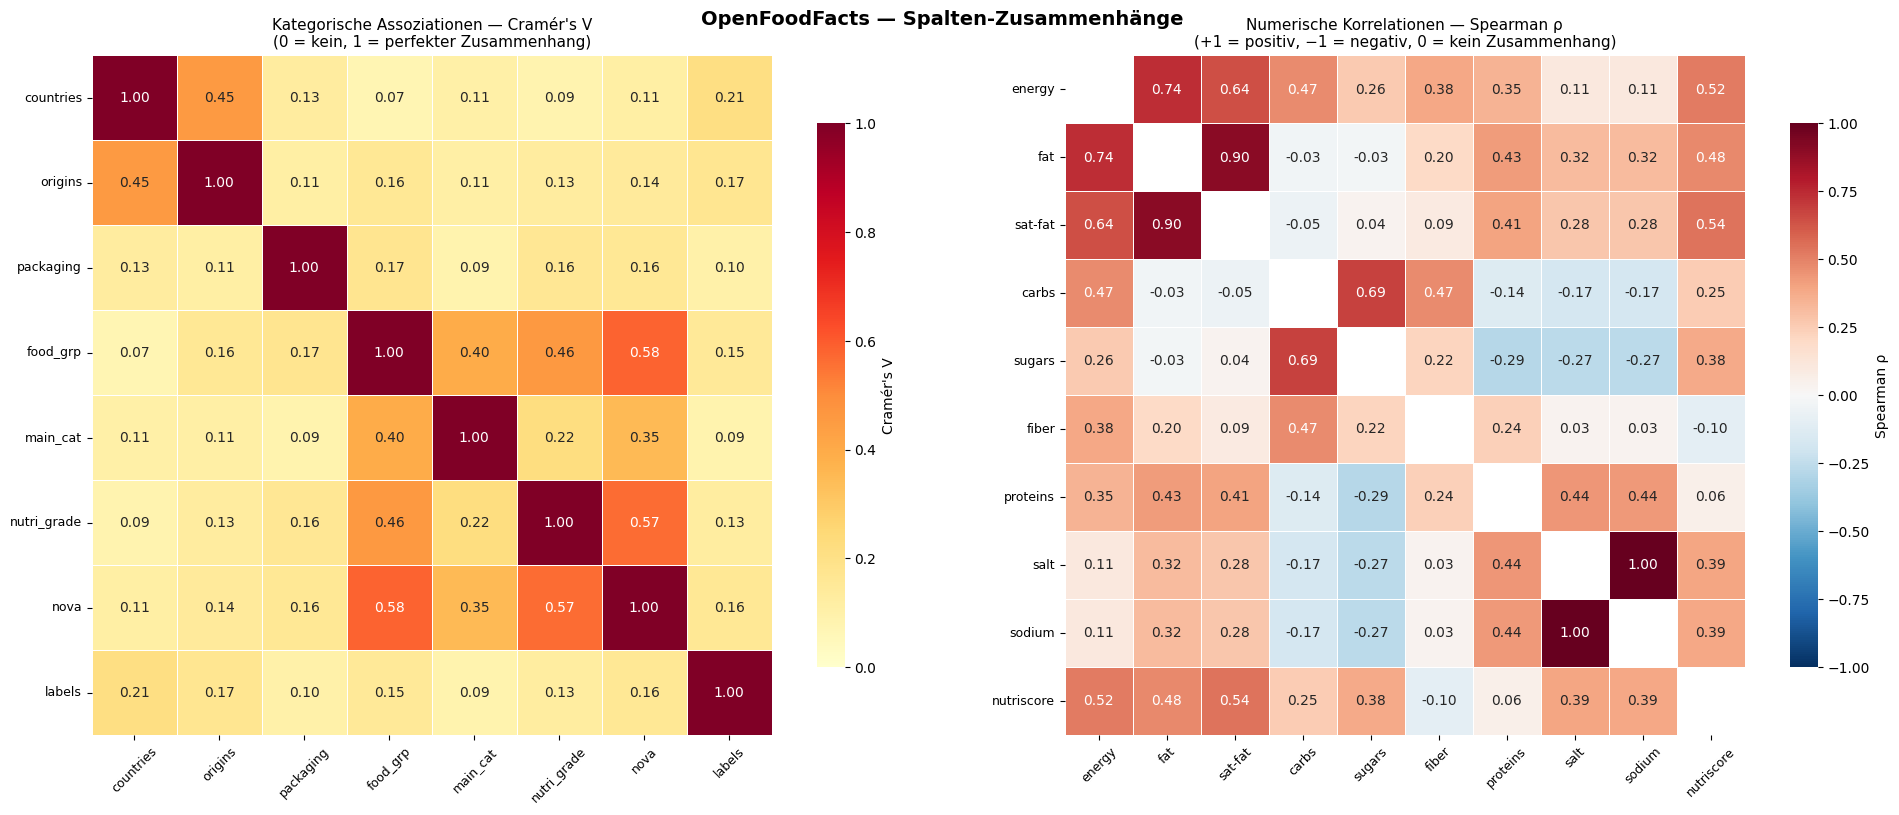

Gespeichert → ../Grafiken Meme/association_heatmaps.png


In [15]:
def shorten(name: str) -> str:
    """Spaltennamen kürzen für lesbare Achsenbeschriftung."""
    return (
        name
        .replace("_en", "")
        .replace("_100g", "")
        .replace("_score", "")
        .replace("saturated-fat", "sat-fat")
        .replace("carbohydrates", "carbs")
        .replace("main_category", "main_cat")
        .replace("food_groups", "food_grp")
        .replace("nutriscore_grade", "nutri_grade")
        .replace("nova_group", "nova")
    )

cv_display   = cv_matrix.rename(index=shorten, columns=shorten).astype(float)
corr_display = corr_matrix.rename(index=shorten, columns=shorten)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("OpenFoodFacts — Spalten-Zusammenhänge", fontsize=14, fontweight="bold")

# Cramér's V (kategorisch)
sns.heatmap(
    cv_display,
    ax=axes[0],
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={"label": "Cramér's V", "shrink": 0.8},
)
axes[0].set_title("Kategorische Assoziationen — Cramér's V\n(0 = kein, 1 = perfekter Zusammenhang)", fontsize=11)
axes[0].tick_params(axis="x", rotation=45, labelsize=9)
axes[0].tick_params(axis="y", rotation=0,  labelsize=9)

# Spearman ρ (numerisch) — Diagonale ausblenden
mask_diag = np.eye(len(corr_display), dtype=bool)
sns.heatmap(
    corr_display,
    ax=axes[1],
    annot=True, fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True,
    mask=mask_diag,
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
)
axes[1].set_title("Numerische Korrelationen — Spearman ρ\n(+1 = positiv, −1 = negativ, 0 = kein Zusammenhang)", fontsize=11)
axes[1].tick_params(axis="x", rotation=45, labelsize=9)
axes[1].tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gespeichert → {OUTPUT_PNG}")